<a href="{{ colab_base_laboratorios }}/Laboratorio_03_intuicion_estadistica_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 3: Intuición estadística

**Jhonatan Jurado Rodríguez**

In [4]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, learning_curve

## Punto 1: Distribuciones de probabilidad y gráfico

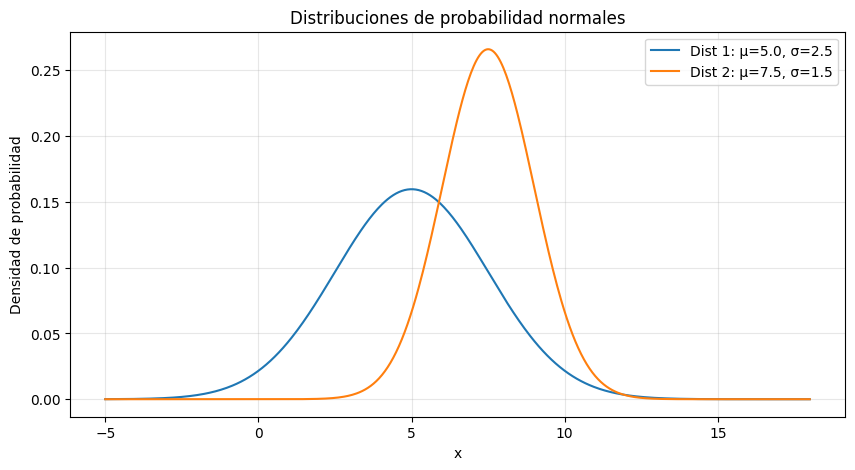

In [5]:
# 1a) Definir las dos distribuciones normales
mean1, std1 = 5.0, 2.5
mean2, std2 = 7.5, 1.5

f1 = stats.norm(loc=mean1, scale=std1)
f2 = stats.norm(loc=mean2, scale=std2)

# 1b) Graficar ambas distribuciones (PDF)
x = np.linspace(-5, 18, 500)

plt.figure(figsize=(10, 5))
plt.plot(x, f1.pdf(x), label=f'Dist 1: μ={mean1}, σ={std1}')
plt.plot(x, f2.pdf(x), label=f'Dist 2: μ={mean2}, σ={std2}')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.title('Distribuciones de probabilidad normales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Punto 2: Frontera analítica

La frontera de decisión se obtiene igualando las dos PDF:

$$f_1(x) = f_2(x)$$

$$\frac{1}{\sigma_1\sqrt{2\pi}} \exp\left(-\frac{(x-\mu_1)^2}{2\sigma_1^2}\right) = \frac{1}{\sigma_2\sqrt{2\pi}} \exp\left(-\frac{(x-\mu_2)^2}{2\sigma_2^2}\right)$$

Tomando logaritmo y simplificando se obtiene una ecuación cuadrática en $x$. Los puntos donde ambas densidades se cruzan son la frontera analítica.

Fronteras analíticas en x = 5.8921 y x = 11.9204


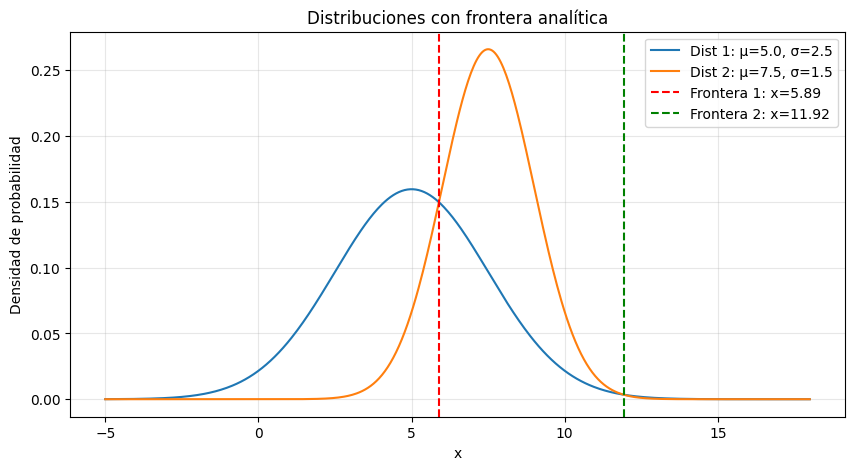

In [6]:
# 2. Cálculo de la frontera analítica (intersección de las dos PDF)
# Igualamos f1(x) = f2(x) y tomamos logaritmo:
# -(x-mu1)^2/(2*s1^2) - ln(s1) = -(x-mu2)^2/(2*s2^2) - ln(s2)
# Reordenando: A*x^2 + B*x + C = 0

A = 1/(2*std1**2) - 1/(2*std2**2)
B = mean2/(std2**2) - mean1/(std1**2)
C = mean1**2/(2*std1**2) - mean2**2/(2*std2**2) - np.log(std2/std1)

discriminante = B**2 - 4*A*C
x_frontera_1 = (-B + np.sqrt(discriminante)) / (2*A)
x_frontera_2 = (-B - np.sqrt(discriminante)) / (2*A)

print(f"Fronteras analíticas en x = {x_frontera_1:.4f} y x = {x_frontera_2:.4f}")

# Graficar con las fronteras
plt.figure(figsize=(10, 5))
plt.plot(x, f1.pdf(x), label=f'Dist 1: μ={mean1}, σ={std1}')
plt.plot(x, f2.pdf(x), label=f'Dist 2: μ={mean2}, σ={std2}')
plt.axvline(x_frontera_1, color='red', linestyle='--', label=f'Frontera 1: x={x_frontera_1:.2f}')
plt.axvline(x_frontera_2, color='green', linestyle='--', label=f'Frontera 2: x={x_frontera_2:.2f}')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.title('Distribuciones con frontera analítica')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Punto 3: Generar 100 muestras aleatorias para cada distribución

In [7]:
# 3. Generar 100 muestras aleatorias para cada distribución (datos de entrenamiento)
n_train = 100
samples_1 = f1.rvs(size=n_train)
samples_2 = f2.rvs(size=n_train)

print(f"Muestras distribución 1: {samples_1[:5]}... (total: {len(samples_1)})")
print(f"Muestras distribución 2: {samples_2[:5]}... (total: {len(samples_2)})")

Muestras distribución 1: [7.55491293 0.21572773 8.40338705 6.87023696 3.27602483]... (total: 100)
Muestras distribución 2: [8.78936743 7.37619181 9.07096611 7.66314368 8.30759528]... (total: 100)


## Punto 4: Gráfico superponiendo ambas distribuciones de muestras

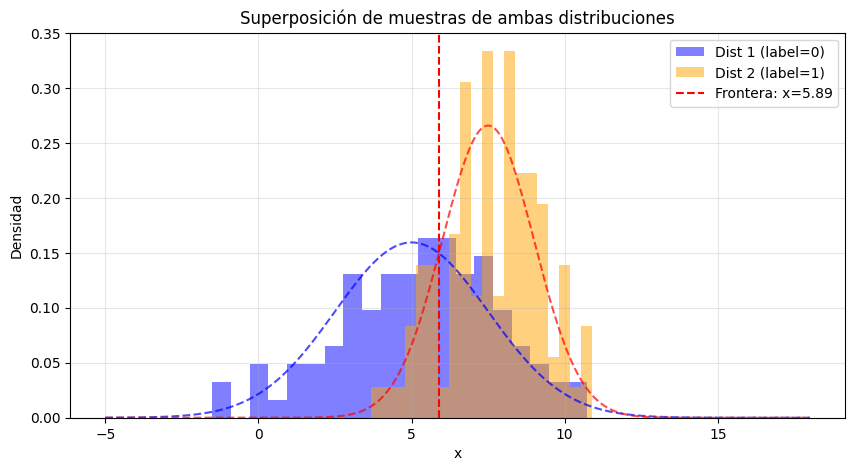

In [8]:
# 4. Gráfico con histogramas superpuestos y etiquetas 0/1
plt.figure(figsize=(10, 5))
plt.hist(samples_1, bins=20, alpha=0.5, label='Dist 1 (label=0)', color='blue', density=True)
plt.hist(samples_2, bins=20, alpha=0.5, label='Dist 2 (label=1)', color='orange', density=True)
plt.plot(x, f1.pdf(x), 'b--', alpha=0.7)
plt.plot(x, f2.pdf(x), 'r--', alpha=0.7)
plt.axvline(x_frontera_1, color='red', linestyle='--', label=f'Frontera: x={x_frontera_1:.2f}')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title('Superposición de muestras de ambas distribuciones')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Punto 5: DataFrame de entrenamiento

In [9]:
# 5. Construir DataFrame de entrenamiento con features (X) y labels (Y)
X_train_data = np.concatenate([samples_1, samples_2])
Y_train_data = np.concatenate([np.zeros(n_train), np.ones(n_train)])

df_train = pd.DataFrame({
    'Y': Y_train_data.astype(int),
    'X': X_train_data
})

print(f"Shape del DataFrame de entrenamiento: {df_train.shape}")
df_train.head(10)

Shape del DataFrame de entrenamiento: (200, 2)


,Y,X
0,0,7.554913
1,0,0.215728
2,0,8.403387
3,0,6.870237
4,0,3.276025
5,0,6.296720
6,0,3.032207
7,0,2.123164
8,0,7.206644
9,0,6.310818


## Punto 6: DataFrame de test

In [10]:
# 6. Construir DataFrame de test con 50 datos (25 de cada distribución)
n_test = 25
test_samples_1 = f1.rvs(size=n_test)
test_samples_2 = f2.rvs(size=n_test)

X_test_data = np.concatenate([test_samples_1, test_samples_2])
Y_test_data = np.concatenate([np.zeros(n_test), np.ones(n_test)])

df_test = pd.DataFrame({
    'Y': Y_test_data.astype(int),
    'X': X_test_data
})

print(f"Shape del DataFrame de test: {df_test.shape}")
df_test.head(10)

Shape del DataFrame de test: (50, 2)


,Y,X
0,0,2.430711
1,0,6.797976
2,0,0.441021
3,0,4.376101
4,0,4.682926
5,0,6.065541
6,0,7.234715
7,0,2.602587
8,0,2.716672
9,0,7.369316


## Punto 7: Clasificadores de Machine Learning

In [11]:
# 7. Clasificadores: LinearRegression, DecisionTree, SVC
X_train = df_train[['X']].values
Y_train = df_train['Y'].values
X_test = df_test[['X']].values
Y_test = df_test['Y'].values

# --- Regresión Lineal ---
regr = LinearRegression()
regr.fit(X_train, Y_train)
score_train_lr = regr.score(X_train, Y_train)
score_test_lr = regr.score(X_test, Y_test)
print(f"Linear Regression - Score train: {score_train_lr:.4f}, Score test: {score_test_lr:.4f}")

# --- Decision Tree Classifier ---
clf_dt = DecisionTreeClassifier(max_depth=3)
clf_dt.fit(X_train, Y_train)
score_train_dt = clf_dt.score(X_train, Y_train)
score_test_dt = clf_dt.score(X_test, Y_test)
print(f"DecisionTree       - Score train: {score_train_dt:.4f}, Score test: {score_test_dt:.4f}")

# --- SVC ---
clf_svc = SVC(kernel="linear", C=0.025)
clf_svc.fit(X_train, Y_train)
score_train_svc = clf_svc.score(X_train, Y_train)
score_test_svc = clf_svc.score(X_test, Y_test)
print(f"SVC (linear)       - Score train: {score_train_svc:.4f}, Score test: {score_test_svc:.4f}")

print("\nConclusión: Los clasificadores muestran scores similares en train y test,")
print("lo que indica que no hay sobreajuste significativo. Las distribuciones tienen")
print("solapamiento, por lo que ningún modelo puede clasificar perfectamente.")

Linear Regression - Score train: 0.2440, Score test: 0.2785
DecisionTree       - Score train: 0.7800, Score test: 0.8200
SVC (linear)       - Score train: 0.7350, Score test: 0.7800

Conclusión: Los clasificadores muestran scores similares en train y test,
lo que indica que no hay sobreajuste significativo. Las distribuciones tienen
solapamiento, por lo que ningún modelo puede clasificar perfectamente.


## Punto 8: GridSearchCV para optimizar hiperparámetros

In [12]:
# 8. GridSearchCV para optimizar DecisionTreeClassifier
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'criterion': ['gini', 'entropy']
}

clf_grid = DecisionTreeClassifier()
CV_clf = GridSearchCV(estimator=clf_grid, param_grid=param_grid, cv=10)
CV_clf.fit(X_train, Y_train)

print(f"Mejores parámetros: {CV_clf.best_params_}")
print(f"Mejor score (CV): {CV_clf.best_score_:.4f}")
print(f"Score en test: {CV_clf.score(X_test, Y_test):.4f}")

Mejores parámetros: {'criterion': 'gini', 'max_depth': 4}
Mejor score (CV): 0.6750
Score en test: 0.8000


## Punto 9: Curvas de aprendizaje

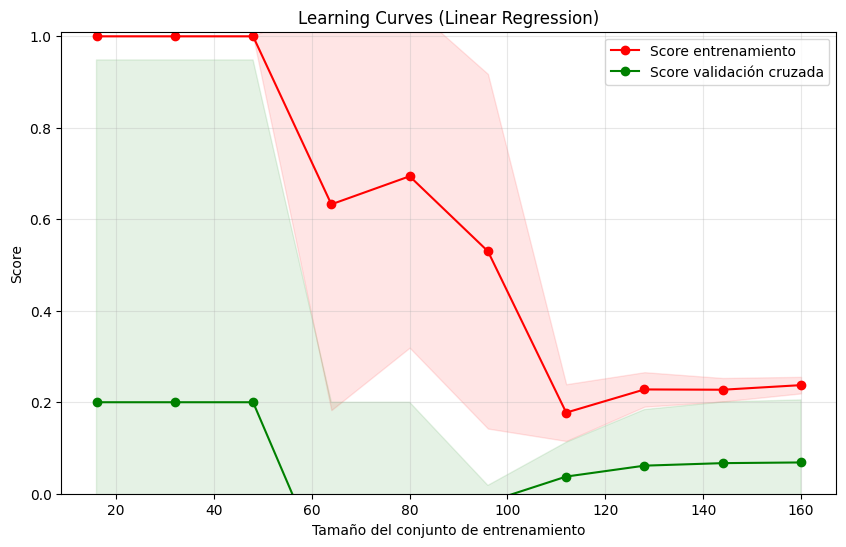

In [13]:
# 9. Función para graficar curvas de aprendizaje
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5, n_jobs=4,
                        train_sizes=np.linspace(0.1, 1.0, 10)):
    """Grafica las curvas de aprendizaje de un modelo."""
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Tamaño del conjunto de entrenamiento")
    plt.ylabel("Score")

    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid(True, alpha=0.3)
    plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r", label="Score entrenamiento")
    plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="g", label="Score validación cruzada")
    plt.legend(loc="best")
    plt.show()

# Curva de aprendizaje para la regresión lineal con los datos actuales
title = "Learning Curves (Linear Regression)"
plot_learning_curve(regr, title, X_train, Y_train, ylim=(0.0, 1.01), n_jobs=4)

## Punto 10: Curvas de aprendizaje variando parámetros

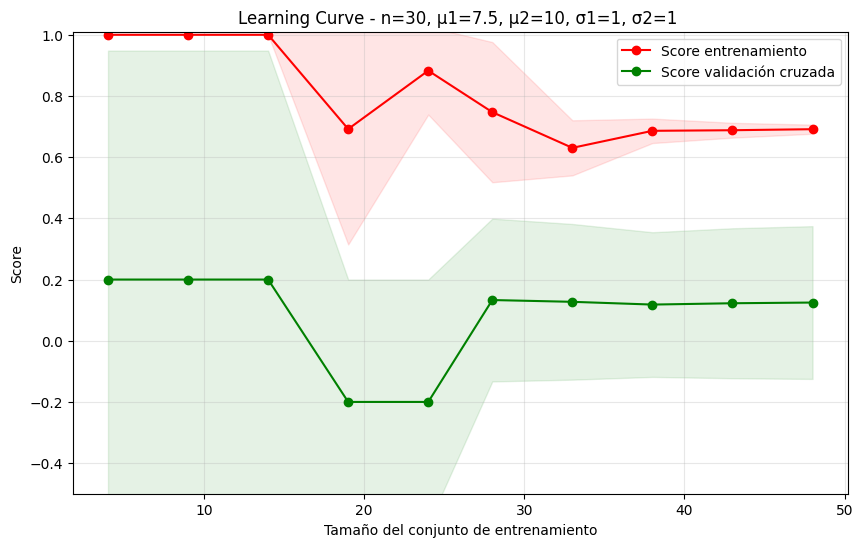

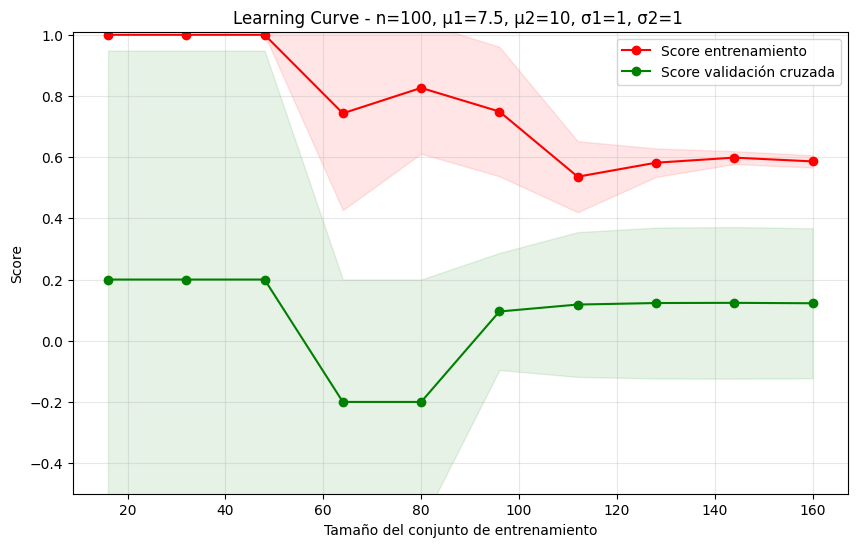

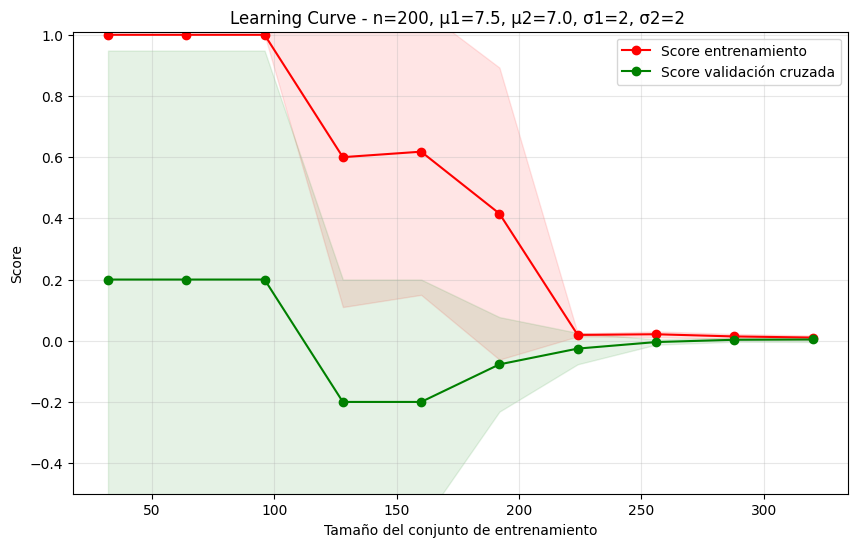

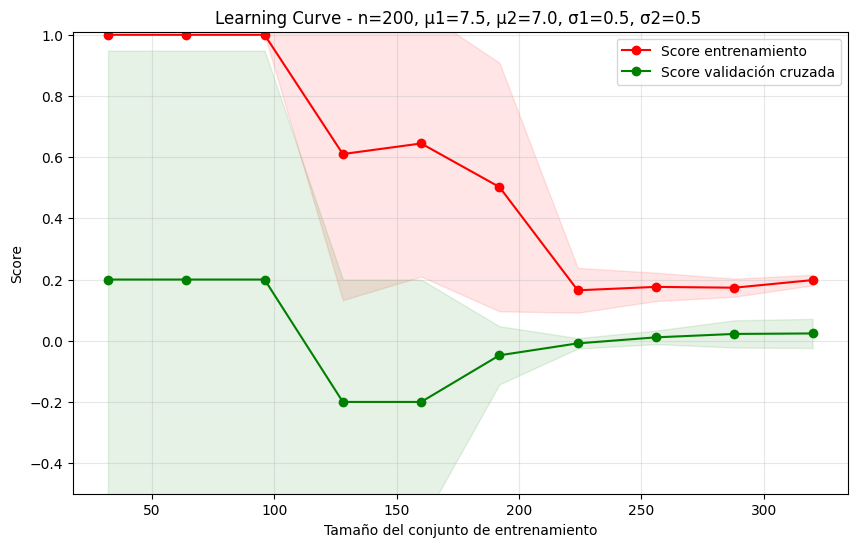

In [14]:
# 10. Función estructurada para generar datos y curvas de aprendizaje
def generar_y_evaluar(n_train, mu1, mu2, s1, s2, titulo_extra=""):
    """Genera distribuciones, datos y curvas de aprendizaje."""
    dist1 = stats.norm(loc=mu1, scale=s1)
    dist2 = stats.norm(loc=mu2, scale=s2)

    samples_a = dist1.rvs(size=n_train)
    samples_b = dist2.rvs(size=n_train)

    X_data = np.concatenate([samples_a, samples_b]).reshape(-1, 1)
    Y_data = np.concatenate([np.zeros(n_train), np.ones(n_train)])

    modelo = LinearRegression()
    modelo.fit(X_data, Y_data)

    title = (f"Learning Curve - n={n_train}, "
             f"μ1={mu1}, μ2={mu2}, σ1={s1}, σ2={s2} {titulo_extra}")
    plot_learning_curve(modelo, title, X_data, Y_data, ylim=(-0.5, 1.01), n_jobs=4)

# Caso 1: n=30, medias separadas, desv=1
generar_y_evaluar(30, 7.5, 10, 1, 1)

# Caso 2: n=100, medias separadas, desv=1
generar_y_evaluar(100, 7.5, 10, 1, 1)

# Caso 3: n=200, medias cercanas, desv=2 (mucho solapamiento)
generar_y_evaluar(200, 7.5, 7.0, 2, 2)

# Caso 4: n=200, medias cercanas, desv=0.5 (poco solapamiento)
generar_y_evaluar(200, 7.5, 7.0, 0.5, 0.5)

## Conclusiones del Punto 10

**Caso 1** (n=30, μ1=7.5, μ2=10, σ=1): Con pocas muestras y distribuciones bien separadas, el modelo aprende rápido pero las curvas muestran alta varianza por la poca cantidad de datos.

**Caso 2** (n=100, μ1=7.5, μ2=10, σ=1): Más datos con distribuciones separadas permiten que el modelo sea más estable. Las curvas convergen mejor y el score mejora.

**Caso 3** (n=200, μ1=7.5, μ2=7.0, σ=2): Mucho solapamiento entre distribuciones (medias cercanas + alta desviación). El modelo tiene dificultades para clasificar, los scores son bajos incluso con muchos datos. Se evidencia un problema intrínseco de los datos, no del modelo.

**Caso 4** (n=200, μ1=7.5, μ2=7.0, σ=0.5): Medias cercanas pero desviación baja, las distribuciones se separan mejor. El modelo logra un score alto. Reducir la varianza compensa la cercanía de las medias.

**Conclusión general**: La separabilidad de los datos depende tanto de la distancia entre medias como de la desviación estándar. Mayor cantidad de datos mejora la estabilidad del modelo pero no puede superar la limitación intrínseca de datos muy solapados.